/opt/conda/envs/km310gpu/lib/python3.10/site-packages/cupyx/jit/_interface.py:173: FutureWarning: cupyx.jit.rawkernel is experimental. The interface can change in the future.
  cupy._util.experimental('cupyx.jit.rawkernel')
INFO:purepyindi2.transports:Connected to localhost:7624


Directory '/data/users/kianmilani/20260710' already exists.
0.30066145520144316


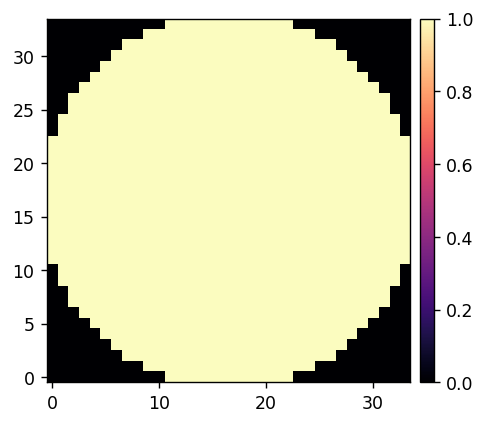

In [2]:
import numpy as np
import astropy.units as u
from astropy.io import fits
import time 
from importlib import reload
import copy
from datetime import datetime
today = int(datetime.today().strftime('%Y%m%d'))
from IPython.display import clear_output
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle, Rectangle

import lina
from lina.math_module import xp, xcipy, ensure_np_array
from lina import iefc, dm, utils, rt_utils, coro_utils, scoob_utils

from magpyx.utils import ImageStream
import purepyindi
from purepyindi import INDIClient
import purepyindi2
from purepyindi2 import IndiClient

client0 = INDIClient('localhost', 7624)
client0.start()
client = IndiClient()
client.connect()
client.get_properties()

data_path = Path(f'/data/users/kianmilani/{today}')
utils.make_dir(data_path)

def restart_clients():
    client0 = INDIClient('localhost', 7624)
    client0.start()

    client = IndiClient()
    client.connect()
    client.get_properties()

Nact = 34
ncamsci = 256
camsci_pxscl_lamDc = 1/3.326
print(camsci_pxscl_lamDc)

dm_mask = dm.create_mask(Nact=34)
utils.imshow([dm_mask])

In [3]:
204/20 * 1024 / 3600

2.901333333333333

In [14]:
reload(scoob_utils)

camsci_channel = 'camsci'

xc, yc = (4320, 3760)
ncamsci = 256
# ncamsci = 512
# ncamsci = 1024
# coro_utils.set_zwo_roi(xc, yc, npsf, client0)

scoob_utils.set_cam_roi(xc, yc, ncamsci, client0, cam_name=camsci_channel, delay=0.5)
scoob_utils.set_cam_exp_time(0.001, client0, cam_name=camsci_channel)
scoob_utils.set_cam_gain(120, client0, cam_name=camsci_channel)
scoob_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set camsci ROI.
Set the camsci exposure time to 1.00e-03s
Set the camsci gain setting to 120.0
Set the camsci blacklevel to 2.0


In [21]:
scoob_utils.set_cam_exp_time(0.003, client0, cam_name=camsci_channel)

Set the camsci exposure time to 3.00e-03s


In [20]:
scoob_utils.set_cam_gain(120, client0, cam_name=camsci_channel)

Set the camsci gain setting to 120.0


In [5]:
scoob_utils.set_cam_blacklevel(2, client0, cam_name=camsci_channel)

Set the camsci blacklevel to 2.0


In [ ]:
reload(coro_utils)
scoob_utils.set_fiber_atten(0, client0) # 132.3 nW

Set the fiber attenuation to 0.0


In [40]:
reload(scoob_utils)
scoob_utils.move_psf(-1, 0, client0)

In [32]:
reload(scoob_utils)
scoob_utils.move_psf(0, -1, client0)

In [ ]:
reload(coro_utils)
scoob_utils.set_fiber_atten(0, client0) # 132.3 nW

Set the fiber attenuation to 0.0


# Test fiberatten and power levels

In [ ]:
reload(coro_utils)
scoob_utils.set_fiber_atten(5, client0) # 47.6 nW

Set the fiber attenuation to 5.0


In [ ]:
scoob_utils.set_fiber_atten(10, client0) # 13.6 nW

Set the fiber attenuation to 10.0


In [ ]:
scoob_utils.set_fiber_atten(15, client0) # 4.7 nW

Set the fiber attenuation to 15.0


In [ ]:
scoob_utils.set_fiber_atten(17.5, client0) # 3.04 nW

Set the fiber attenuation to 17.5


In [ ]:
scoob_utils.set_fiber_atten(20, client0) # 2.120 nW

Set the fiber attenuation to 20.0


In [ ]:
scoob_utils.set_fiber_atten(25, client0) # 1.270 nW

Set the fiber attenuation to 25.0


In [ ]:
scoob_utils.set_fiber_atten(30, client0) # 850 pW

Set the fiber attenuation to 30.0


In [15]:
scoob_utils.set_fiber_atten(35, client0) # 620 pW

Set the fiber attenuation to 35.0


In [ ]:
scoob_utils.set_fiber_atten(40, client0) # 480 pW

Set the fiber attenuation to 40.0


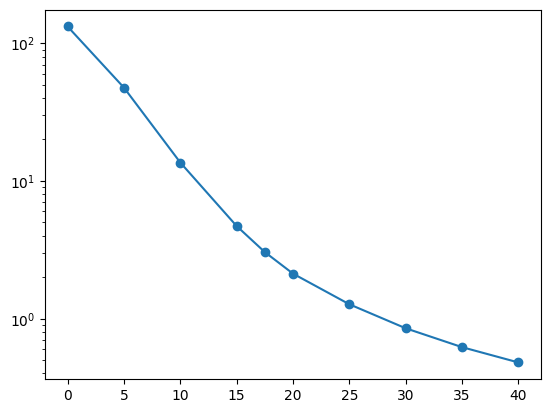

In [12]:
power_vs_fiberatten = np.array(
    [[0, 5, 10, 15, 17.5, 20, 25, 30, 35, 40],
     [132.3, 47.6, 13.6, 4.7, 3.04, 2.12, 1.27, 0.85, 0.62, 0.48]],
)

np.savetxt(
    data_path/'powermeter_vs_fiberatten_data.csv',
    power_vs_fiberatten,
    delimiter=',',
)

plt.semilogy(power_vs_fiberatten[0], power_vs_fiberatten[1], marker='o')

In [18]:
scoob_utils.set_fiber_atten(0, client)

Set the fiber attenuation to 0.0


In [ ]:
reload(scoob_utils)

scoob_utils.home_filter_stage(client0)

In [55]:

scoob_utils.set_filter_stage_velocity(client0, 60, )

In [ ]:
scoob_utils.set_filter_stage_angle(client0, 37, )

In [60]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f1', )

In [59]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f2', )

In [58]:
reload(scoob_utils)
scoob_utils.set_filter_stage_preset(client0, 'f3', )

In [31]:

CAMSCI_STREAM = ImageStream('camsci')

dm_channel = 'dm00disp03'
DM_STREAM = ImageStream(dm_channel)


In [34]:
def take_im_fun(CAMSCI_STREAM, NFRAMES=10):
    coro_im = xp.array(np.mean(CAMSCI_STREAM.grab_many(NFRAMES), axis=0))
    return coro_im

take_im_params = {
    'CAMSCI_STREAM':CAMSCI_STREAM,
    'NFRAMES':10,
}

def set_dm_fun(command, DM_STREAM, wait_time=0.02):
    DM_STREAM.write(ensure_np_array(command)*1e6)
    time.sleep(wait_time)
    return

set_dm_params = {
    'DM_STREAM':DM_STREAM,
    'wait_time':0.05,
}


In [37]:
take_im_params = {
    'CAMSCI_STREAM':CAMSCI_STREAM,
    'NFRAMES':100,
}

post_camera_cooling_im = take_im_fun(**take_im_params)

utils.save_fits(
    data_path/f'post_camera_cooling_im_without_adjusted_flat_{today}.fits',
    post_camera_cooling_im,
    # header={'ASTIGO':0.010,},
)

Saved data to:  /data/users/kianmilani/20260710/post_camera_cooling_im_without_adjusted_flat_20260710.fits
